## Análisis de Componentes Principales (PCA)



El **Análisis de Componentes Principales (PCA)** es una técnica de reducción de dimensionalidad que transforma un conjunto de variables originales, posiblemente correlacionadas entre sí, en un nuevo conjunto de variables denominadas componentes principales.

Cada componente principal es una combinación lineal de las variables originales y se construye de manera que capture la mayor cantidad posible de variabilidad de los datos. Las componentes se obtienen en orden decreciente de importancia: la primera componente explica la mayor proporción de la variabilidad, la segunda explica la mayor proporción de la variabilidad restante, y así sucesivamente.

En este proyecto, PCA se utiliza después del análisis exploratorio de datos, donde se identificaron relaciones elevadas y redundancias entre algunos indicadores financieros. El objetivo es obtener una representación más compacta y no redundante de los **24 indicadores**, conservando la mayor cantidad posible de información estadística para posteriormente utilizarla en el análisis de *clustering*.

**Interpretación geométrica**

Geométricamente, cada observación de la base de datos puede representarse como un punto en un espacio de:

$$
p=24
$$

dimensiones, donde cada eje corresponde a un indicador financiero.

Antes de aplicar PCA, se estandarizan las variables mediante el **Z-score**:

$$
z_{ij}=\frac{x_{ij}-\bar{x}_j}{s_j}
$$

De esta manera, las variables quedan expresadas en una escala comparable, con media aproximadamente igual a cero y desviación estándar muestral aproximadamente igual a uno. Esta transformación es importante en nuestro conjunto de datos porque los indicadores financieros presentan **diferentes escalas y unidades de medida**, evitando que una variable domine el análisis únicamente por tener una magnitud numérica mayor.

La estandarización ***no elimina los valores atípicos***; estos permanecen en los datos y continúan aportando información al PCA.

**Nuevas direcciones de variabilidad**

A partir de la matriz estandarizada $Z$, PCA busca nuevas direcciones dentro del espacio original:

$$
v_1,v_2,\ldots,v_p
$$

Estas direcciones corresponden a las **componentes principales** y se encuentran ordenadas según la cantidad de varianza que explican.

La primera dirección $v_1$ es aquella en la que los datos presentan la **máxima varianza posible**. La segunda dirección $v_2$ captura la mayor cantidad de varianza restante, bajo la condición de ser ortogonal a $v_1$. El procedimiento continúa de la misma manera para las siguientes componentes.

Cada componente constituye una nueva coordenada de los datos. Por ejemplo:

$$
PC_1=Zv_1
$$

$$
PC_2=Zv_2
$$

y, en general:

$$
\boxed{PC_k=Zv_k}
$$

Por tanto, PCA puede interpretarse geométricamente como una **rotación del sistema de coordenadas original** hacia un nuevo sistema de ejes que representa las principales direcciones de variabilidad de los datos.

El objetivo no es eliminar observaciones ni indicadores directamente, sino **transformar las variables originales en nuevas dimensiones no correlacionadas**. Posteriormente, podemos seleccionar las primeras componentes que concentran una proporción suficiente de la varianza para representar los datos con menor dimensionalidad.

**Objetivo dentro del proyecto**

En términos prácticos, PCA permite pasar de los **24 indicadores financieros originales** a un conjunto reducido de componentes principales que concentran gran parte de la variabilidad de los datos, facilitando su utilización en la etapa posterior de *clustering*.

La secuencia metodológica es:

$$
\boxed{
\text{24 indicadores}
\rightarrow
\text{Estandarización}
\rightarrow
\text{PCA}
\rightarrow
\text{Componentes principales}
\rightarrow
\text{Selección de componentes}
\rightarrow
\text{Clustering}
}
$$

## Carga de las librerías y de los módulos

In [1]:
from pathlib import Path

RAIZ_PROYECTO = "."

In [2]:
from pathlib import Path
import sys

# Convertir la ruta recibida a un objeto Path
RAIZ_PROYECTO = Path(RAIZ_PROYECTO)

# Si el notebook se ejecuta directamente desde la carpeta notebooks,
# la raíz del proyecto corresponde al directorio padre.
if str(RAIZ_PROYECTO) == ".":
    RAIZ_PROYECTO = Path.cwd().parent
else:
    RAIZ_PROYECTO = RAIZ_PROYECTO.resolve()

# Agregar la raíz del proyecto al buscador de módulos de Python
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

In [3]:
import os
import matplotlib
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import sys
import pandas as pd
import importlib

## Carga del dataset y definición de variables que participan en el PCA

In [4]:
ruta_entrada = RAIZ_PROYECTO / "data_processed" / "base_pca2.xlsx"

base_pca = pd.read_excel(ruta_entrada)

In [5]:
base_pca.shape

(1207, 27)

In [6]:
meses = {
    "enero": 1,
    "febrero": 2,
    "marzo": 3,
    "abril": 4,
    "mayo": 5,
    "junio": 6,
    "julio": 7,
    "agosto": 8,
    "septiembre": 9,
    "octubre": 10,
    "noviembre": 11,
    "diciembre": 12
}

# Crear número de mes
base_pca["MES_NUM"] = base_pca["MES"].str.lower().map(meses)

# Crear fecha
base_pca["FECHA"] = pd.to_datetime(
    base_pca["AÑO"].astype(str) + "-" +
    base_pca["MES_NUM"].astype(str) + "-01"
)

In [7]:
# Variables que NO entran al PCA
variables_identificacion = [
    "ENTIDAD",
    "MES",
    "AÑO",
    "MES_NUM",
    "FECHA"
]


variables_pca = [
    col for col in base_pca.columns
    if col not in variables_identificacion
]

In [8]:
print("Número de variables para PCA:", len(variables_pca))
print("\nVariables seleccionadas:")
for i, variable in enumerate(variables_pca, start=1):
    print(f"{i:02d}. {variable}")

Número de variables para PCA: 24

Variables seleccionadas:
01. SUFICIENCIA PATRIMONIAL
02. INDICE DE CAPITALIZACION NETO: FK / FI
03. ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS
04. ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO
05. MOROSIDAD DE LA CARTERA TOTAL
06. COBERTURA DE LA CARTERA REFINANCIADA
07. COBERTURA DE LA CARTERA REESTRUCTURADA
08. COBERTURA DE LA CARTERA PROBLEMÁTICA
09. GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3)
10. GASTOS DE OPERACION  / MARGEN FINANCIERO
11. GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3)
12. RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO
13. RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO
14. CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSITOS A PLAZO)
15. FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO PLAZO
16. CARTERA REFINANCIADA / CARTERA BRUTA
17. CARTERA REESTRUCTURADA / CARTERA BRUTA
18. VAR_FONDOS DISPONIBLES
19. VAR_INVERSIONES
20. VAR_CARTERA DE CRÉDITOS
21. VAR_TOTAL ACTIVO
22. VAR_Depósitos a la vista
23. VAR_Depósitos a plazo
24. VAR_TOTAL 

## 1. Definición de la matriz X

In [9]:
X = base_pca[variables_pca].copy()

print("Dimensiones de X:", X.shape)

Dimensiones de X: (1207, 24)


### Formulación matemática

Sea:

$$
X\in\mathbb{R}^{n\times p}
$$

donde:

- $n$ = número de observaciones.
- $p$ = número de variables originales.

Por tanto, la  matriz $X$ contiene las variables financieras que ingresarán al PCA.

$$
X=
\begin{bmatrix}
x_{11}&x_{12}&\cdots&x_{1p}\\
x_{21}&x_{22}&\cdots&x_{2p}\\
\vdots&\vdots&\ddots&\vdots\\
x_{n1}&x_{n2}&\cdots&x_{np}
\end{bmatrix}
$$

En este proyecto:

$$
X\in\mathbb{R}^{1207\times24}
$$

donde:

- $n=1207$: observaciones banco-mes-año.
- $p=24$: indicadores financieros que ingresan al PCA.
- Cada fila representa una observación.
- Cada columna representa un indicador financiero.

Las variables de identificación como entidad, año, mes y fecha no participan en el PCA porque no representan dimensiones financieras continuas.

PCA busca construir nuevas variables:

$$
PC_k = Z v_k
$$

donde:

- $Z$ es la matriz estandarizada.
- $v_k$ es la dirección asociada a la componente $k$.
- $PC_k$ contiene las coordenadas de las observaciones sobre dicha dirección.

Los vectores $v_k$ se obtienen a partir de los vectores singulares derechos de la descomposición SVD.

Verificamos que nuestra matriz X no tenga nulos.

In [10]:
nulos_pca = X.isna().sum()

print("Valores nulos por variable:")
print(nulos_pca[nulos_pca > 0])

Valores nulos por variable:
Series([], dtype: int64)


In [11]:
if X.isna().sum().sum() > 0:
    raise ValueError(
        "Existen valores nulos en las variables seleccionadas para PCA. "
        "Debe completarse el tratamiento de valores faltantes antes de continuar."
    )

## 2. Estandarización

Las variables financieras presentan diferentes unidades y escalas, y como vimos en el EDA presentan una gran cantidad de atípicos dada la variabilidad de entidades  que se analizan.

Para evitar que la escala de una variable determine su influencia sobre el PCA, cada variable se estandariza mediante:

$$
z_{ij}=
\frac{x_{ij}-\bar{x}_j}{s_j}
$$

donde:

- $x_{ij}$ es el valor de la variable $j$ para la observación $i$.
- $\bar{x}_j$ es la media de la variable $j$.
- $s_j$ es su desviación estándar muestral.
- $z_{ij}$ es el valor estandarizado.

Como resultado:

$$
\bar{z}_j\approx0
$$

y

$$
s_j\approx1
$$

para cada variable.

In [12]:

X_np = X.to_numpy(dtype=float)

# Media de cada variable
media = np.mean(X_np, axis=0)

# Desviación estándar muestral
desv = np.std(X_np, axis=0, ddof=1)

# Estandarización
Z = (X_np - media) / desv

In [13]:
print("Media aproximada:")
print(np.mean(Z, axis=0))

print("\nDesviación estándar:")
print(np.std(Z, axis=0, ddof=1))

Media aproximada:
[ 0.00000000e+00 -6.47553446e-17 -6.59327145e-16 -1.53058087e-16
 -3.53210971e-17  2.35473980e-17 -1.47171238e-17 -2.94342475e-18
  1.64831786e-16 -3.23776723e-17  2.35473980e-17  1.76605485e-17
  0.00000000e+00 -3.53210971e-17  3.29663573e-16 -3.53210971e-17
  1.41284388e-16 -3.53210971e-17 -2.35473980e-17  1.29510689e-16
  9.41895921e-17  0.00000000e+00 -8.83027426e-18  2.35473980e-17]

Desviación estándar:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 3. Descomposición en Valores Singulares (SVD)



PCA puede calcularse a partir de la descomposición en valores singulares (SVD, Singular Value Decomposition) de la matriz estandarizada $Z$.

La SVD descompone $Z$ como:

$$
\boxed{
Z=U\Sigma V^T
}
$$

donde:

- $U$ contiene los vectores singulares izquierdos que da las direcciones de salida.
- $\Sigma$ contiene los valores singulares que indica la escala de cada componente.
- $V^T$ contiene los vectores singulares derechos transpuestos que da las direcciones de entrada.

Para este proyecto:

$$
Z\in\mathbb{R}^{1207\times24}
$$

y utilizando `full_matrices=False`:

$$
U\in\mathbb{R}^{1207\times24}
$$

$$
\Sigma\in\mathbb{R}^{24\times24}
$$

$$
V^T\in\mathbb{R}^{24\times24}
$$

In [14]:
U, S, Vt = np.linalg.svd(Z,full_matrices=False)

In [15]:
print("Z :", Z.shape)
print("U :", U.shape)
print("S :", S.shape)
print("Vt:", Vt.shape)

Z : (1207, 24)
U : (1207, 24)
S : (24,)
Vt: (24, 24)


**Interpretación de U**

Los vectores singulares izquierdos contenidos en $U$ describen la orientación de las observaciones (FILAS) respecto de las direcciones principales.

Cada columna de $U$ está asociada con una componente principal.

Sin embargo, los valores de $U$ por sí solos no corresponden directamente a los scores. Los scores se obtienen mediante:

$$
T=U\Sigma
$$

Por tanto:

$$
T=ZV=U\Sigma
$$

En este análisis, $U$ aporta la estructura de las observaciones respecto de cada dirección principal, mientras que $\Sigma$ determina la escala asociada a cada dirección.

**Interpretación de V**

Las columnas de $V$ contienen las direcciones principales en el espacio de las variables originales (COLUMNAS).

Si:

$$
V=[v_1,v_2,\ldots,v_p]
$$

entonces cada vector $v_k$ define la dirección de la componente principal $k$.

Por ejemplo:

$$
v_1=
\begin{bmatrix}
v_{11}\\
v_{21}\\
\vdots\\
v_{p1}
\end{bmatrix}
$$

representa la dirección de la primera componente principal en el espacio de las variables originales.

Los elementos de $v_1$ indican cuánto participa cada variable original en la dirección de PC1.

Por esta razón, los vectores de $V$ constituyen la base para interpretar las cargas de las componentes principales.

**Proyección geométrica**

Para una observación $z_i$, su coordenada sobre la primera componente se obtiene mediante:

$$
PC_{i1}=z_i^Tv_1
$$

De forma matricial:

$$
T=ZV
$$

Por tanto, el PCA proyecta cada observación sobre las nuevas direcciones definidas por las columnas de $V$.

Los valores resultantes son los scores de las componentes principales.

## 4. Comprobación de la descomposición

In [16]:
Sigma = np.diag(S)

In [17]:
Z_reconstruida = U @ Sigma @ Vt

In [18]:
error_svd = np.linalg.norm(
    Z - Z_reconstruida
)

print("Error de reconstrucción SVD:", error_svd)

Error de reconstrucción SVD: 5.424397527754078e-13


La reconstrucción se obtiene mediante:

$$
\hat{Z}=U\Sigma V^T
$$

Si la SVD fue calculada correctamente:

$$
Z\approx\hat{Z}
$$

El error de reconstrucción se calcula mediante la norma de Frobenius:

$$
\|Z-\hat{Z}\|_F
$$

La norma de Frobenius es una medida matemática que determina el tamaño o la magnitud de una matriz. 
Se calcula como la raíz cuadrada de la suma de los cuadrados de todos los elementos que componen la matriz. También equivale a la raíz cuadrada de la traza (suma de valores propios) del producto de la matriz por su transpuesta.

Un valor cercano a cero indica que la descomposición reconstruye numéricamente la matriz original con precisión.

## 5. Obtención de componentes principales

Los scores representan las coordenadas de cada observación en el nuevo sistema de referencia definido por las componentes principales.

A partir de:

$$
Z=U\Sigma V^T
$$

se obtiene:

$$
ZV=U\Sigma V^TV
$$

Como $V$ es ortogonal:

$$
V^TV=I
$$

por lo tanto:

$$
\boxed{ZV=U\Sigma}
$$

Así, los scores pueden calcularse de dos formas equivalentes:

$$
T=ZV
$$

o

$$
T=U\Sigma
$$

La equivalencia se verifica numéricamente en el código.

In [19]:
V = Vt.T

In [20]:
scores = Z @ V

In [21]:
scores

array([[ 1.67034234,  0.50237799, -0.04217761, ..., -0.20979646,
         0.0637484 , -0.10005026],
       [-0.11530179,  1.55839354,  0.22462426, ...,  0.10856631,
         0.18918837,  0.10613465],
       [ 1.15617027,  0.98880881,  0.02646163, ..., -0.11418397,
         0.28692467, -0.09510899],
       ...,
       [ 1.42493688, -1.54963859, -4.34871866, ...,  0.03123169,
        -0.57301137, -0.22250328],
       [-0.05792751,  1.33561267,  0.95960395, ...,  0.30408795,
         0.30137078,  0.07207261],
       [ 0.4483166 , -2.97729234, -0.25497144, ..., -0.37990817,
        -0.05266697,  0.13194947]], shape=(1207, 24))

In [22]:
scores_svd = U @ Sigma

In [23]:
error_scores = np.linalg.norm(
    scores - scores_svd
)

print("Error entre ambas formas:", error_scores)

Error entre ambas formas: 5.307385282994986e-13


In [24]:
## Se almacenan los scores calculados en un dataframe con el nombre PC1 (Componente Principal 1), 
## PC2 (Componente Principal 2),.....,etc

n_componentes = scores.shape[1]

nombres_componentes = [
    f"PC{i+1}"
    for i in range(n_componentes)
]

df_scores = pd.DataFrame(
    scores,
    columns=nombres_componentes,
    index=base_pca.index
)

In [25]:
df_scores["ENTIDAD"] = base_pca["ENTIDAD"].values
df_scores["AÑO"] = base_pca["AÑO"].values
df_scores["MES"] = base_pca["MES"].values
df_scores["FECHA"] = base_pca["FECHA"].values

Se almacena en `df_scores` los componentes principales calculados y se añade las correspondientes columnas que determinan la entida,d el año, el mes y la fecha.

In [26]:
df_scores

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC19,PC20,PC21,PC22,PC23,PC24,ENTIDAD,AÑO,MES,FECHA
0,1.670342,0.502378,-0.042178,-0.416485,-0.400375,0.588000,0.064495,0.431002,0.177570,0.118129,...,-0.106885,-0.015775,-0.245932,-0.209796,0.063748,-0.100050,BP GUAYAQUIL,2022,Mayo,2022-05-01
1,-0.115302,1.558394,0.224624,-0.709578,-0.588994,-0.313127,-1.171238,-0.770440,-0.493185,0.053260,...,0.270975,-0.926042,-0.232735,0.108566,0.189188,0.106135,BP PACIFICO,2022,Mayo,2022-05-01
2,1.156170,0.988809,0.026462,-0.498895,-0.637781,1.734360,0.260856,0.023198,0.391105,-0.580334,...,0.064801,0.181013,-0.177316,-0.114184,0.286925,-0.095109,BP PICHINCHA,2022,Mayo,2022-05-01
3,1.640119,0.536627,-0.123829,-0.298324,-0.054004,0.720307,0.467011,0.166455,0.156224,0.035843,...,-0.102163,0.074726,-0.217732,-0.146356,0.015107,-0.132587,BP PRODUBANCO,2022,Mayo,2022-05-01
4,0.613680,1.255829,-0.521440,-0.107046,-0.267844,0.702825,-0.521407,0.085341,0.032046,0.346037,...,0.214884,-0.277598,-0.018936,0.053030,0.148941,-0.127036,BP AUSTRO,2022,Mayo,2022-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202,1.036045,0.227411,-1.546591,0.695227,-0.837032,0.742020,0.968712,0.628746,0.187723,1.542562,...,-0.030495,0.075749,0.131639,0.260643,0.103778,-0.138144,BP CAPITAL,2026,Julio,2026-07-01
1203,-2.120450,-2.090063,2.385544,-0.537215,-0.373405,-1.266998,-1.235508,-0.127112,-0.825867,1.035622,...,-0.134300,-0.583875,0.213329,0.524362,0.192748,0.230196,BP DELBANK,2026,Julio,2026-07-01
1204,1.424937,-1.549639,-4.348719,1.904478,-0.426288,0.884874,2.074304,0.699339,0.063287,1.067194,...,0.748747,1.091838,0.154257,0.031232,-0.573011,-0.222503,BP D-MIRO S.A./BANCO ATLÁNTIDA S.A.,2026,Julio,2026-07-01
1205,-0.057928,1.335613,0.959604,-0.750871,0.050477,0.373853,-0.449851,0.709412,0.316063,-0.246174,...,-0.487970,0.333066,0.564073,0.304088,0.301371,0.072073,"BP BANCO DESARROLLO DE LOS PUEBLOS S.A., COD...",2026,Julio,2026-07-01


## 6. Varianza explicada y porcentaje

Los valores singulares están directamente relacionados con la varianza de las componentes principales.

Los valores singulares son los valores que se obtienen al aplicar la **descomposición en valores singulares (SVD)** sobre la matriz estandarizada $Z$:

$$
Z = U\Sigma V^T
$$

donde $\Sigma$ es una matriz diagonal cuyos elementos son los valores singulares:

$$
\Sigma =
\begin{pmatrix}
\sigma_1 & 0 & \cdots & 0\\
0 & \sigma_2 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \sigma_p
\end{pmatrix}
$$

Los valores singulares se encuentran ordenados de mayor a menor:

$$
\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_p \geq 0
$$

Cada valor singular $\sigma_k$ está asociado con una componente principal $PC_k$ y mide la magnitud de la variabilidad de los datos en la dirección correspondiente a dicha componente.


Una precisión importante es que estos valores singulares no representan directamente la varianza.


Para la componente $k$: $$ \lambda_k= \frac{\sigma_k^2}{n-1} $$ 
donde: 
- $\sigma_k$ es el $k$-ésimo valor singular. 
- $\lambda_k$ es la varianza asociada a la componente $k$. 
- $n$ es el número de observaciones. 

La varianza total es: $$ \sum_{k=1}^{p}\lambda_k $$ y el porcentaje de varianza explicado por la componente $k$ es: $$ \text{Varianza explicada}_k= \frac{\lambda_k} {\sum_{j=1}^{p}\lambda_j} \times100 $$



In [27]:
n = Z.shape[0]

# S es el vector que tiene los valores singulares extraídos de sigma, entonces para obtener 
# la varianza se elevan al cuadrado y se dividen para n-1
varianza_componentes = (S ** 2) / (n - 1)

print(varianza_componentes)

[4.55697278 2.49816116 2.22899533 1.78940945 1.53365601 1.44265484
 1.13630717 1.02747652 0.98831256 0.97728422 0.93061146 0.81563914
 0.75726411 0.63346124 0.56069263 0.49381222 0.45482927 0.34369675
 0.24836743 0.2138077  0.14459937 0.10016022 0.0841064  0.03972204]


In [28]:
varianza_total = np.sum(varianza_componentes)

print("Varianza total:", varianza_total)

Varianza total: 24.0


In [29]:
print("Número de variables:", Z.shape[1])

Número de variables: 24


In [30]:
porcentaje_varianza = (
    varianza_componentes / varianza_total
) * 100

La varianza acumulada hasta la componente $k$ se obtiene mediante:

$$
VEA_k=
\sum_{j=1}^{k}
VE_j
$$

donde $VE_j$ representa el porcentaje de varianza explicado por la componente $j$.

Esta medida permite evaluar cuántas componentes son necesarias para conservar un determinado porcentaje de la variabilidad total.

In [31]:
varianza_acumulada = np.cumsum(porcentaje_varianza)

In [32]:
tabla_varianza = pd.DataFrame({
    "Componente": nombres_componentes,
    "Valor_singular": S,
    "Varianza": varianza_componentes,
    "Porcentaje_varianza": porcentaje_varianza,
    "Varianza_acumulada": varianza_acumulada
})

tabla_varianza

,Componente,Valor_singular,Varianza,Porcentaje_varianza,Varianza_acumulada
0,PC1,74.133050,4.556973,18.987387,18.987387
1,PC2,54.888818,2.498161,10.409005,29.396391
2,PC3,51.847549,2.228995,9.287481,38.683872
3,PC4,46.454578,1.789409,7.455873,46.139745
4,PC5,43.006850,1.533656,6.390233,52.529978
5,PC6,41.711410,1.442655,6.011062,58.541040
6,PC7,37.018731,1.136307,4.734613,63.275653
7,PC8,35.201373,1.027477,4.281152,67.556805
8,PC9,34.523976,0.988313,4.117969,71.674774
9,PC10,34.330814,0.977284,4.072018,75.746792


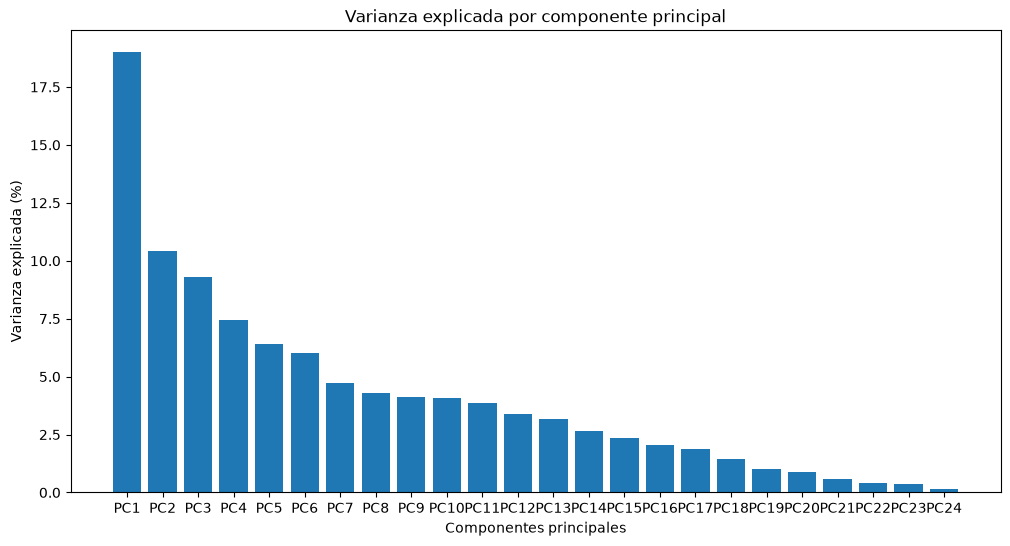

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    nombres_componentes,
    porcentaje_varianza
)

ax.set_xlabel("Componentes principales")
ax.set_ylabel("Varianza explicada (%)")
ax.set_title("Varianza explicada por componente principal")


# Guardar figura como evidencia del análisis de varianza
ruta_figura = RAIZ_PROYECTO / "results" / "varianza_explicada_pca.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

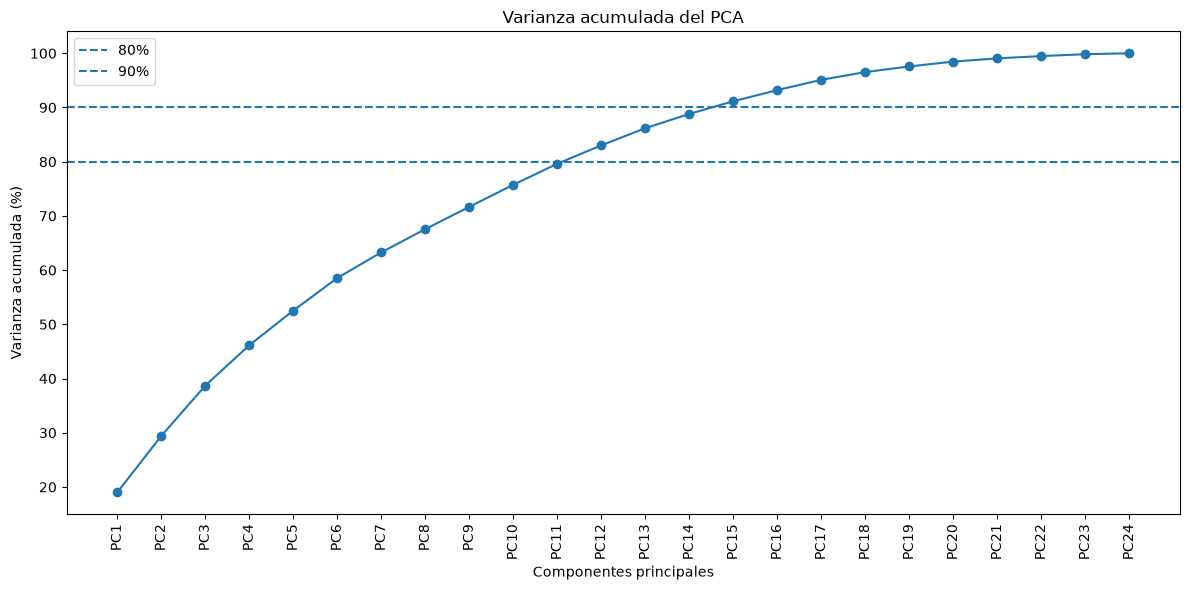

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    nombres_componentes,
    varianza_acumulada,
    marker="o"
)

ax.axhline(80, linestyle="--", label="80%")
ax.axhline(90, linestyle="--", label="90%")

ax.set_xlabel("Componentes principales")
ax.set_ylabel("Varianza acumulada (%)")
ax.set_title("Varianza acumulada del PCA")

plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()

# Guardar figura como evidencia del criterio de selección
ruta_figura = RAIZ_PROYECTO / "results" / "varianza_acumulada_pca.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

Los resultados muestran que la primera componente principal (PC1) explica aproximadamente el 19% de la variabilidad total, mientras que las componentes siguientes aportan proporciones progresivamente menores. La varianza acumulada aumenta hasta aproximadamente el 80% alrededor de las primeras 11–12 componentes y supera el 90% con las primeras 15 componentes. Esto evidencia que una parte importante de la información contenida en los 24 indicadores puede representarse mediante un número reducido de componentes principales. En particular, PC11 representa aproximadamente el 80% de la varianza acumulada, mientras que PC15 alcanza aproximadamente el 91%. Por este motivo, se consideran PC11 y PC15 como dos alternativas de representación de los datos para la etapa posterior de clustering, cuya selección final deberá complementarse con criterios de calidad y estabilidad de los agrupamientos.

## 7. Cargas y contribución de cada componente

### Cargas de los componentes

Las cargas permiten analizar la relación entre las variables originales y las componentes principales.

Si:

$$
\Lambda=
diag(\lambda_1,\ldots,\lambda_p)
$$

las cargas se calculan como:

$$
\boxed{
L=V\Lambda^{1/2}
}
$$

Por tanto, para una variable $j$ y una componente $k$:

$$
l_{jk}=v_{jk}\sqrt{\lambda_k}
$$

Una carga de mayor magnitud indica una mayor asociación de la variable con la componente correspondiente.

El signo indica la dirección de la relación respecto de la componente.

In [35]:
sqrt_lambda = np.sqrt(varianza_componentes)

cargas = V * sqrt_lambda

In [36]:
tabla_cargas = pd.DataFrame(
    cargas,
    index=variables_pca,
    columns=nombres_componentes
)

tabla_cargas

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
SUFICIENCIA PATRIMONIAL,0.038345,-0.004984,0.110523,0.135266,0.006475,-0.115131,-0.091071,-0.179895,0.883192,0.083199,...,-0.025415,-0.011129,0.001741,-0.013970,-0.003577,0.000349,0.000190,0.002968,-0.000339,-0.000506
INDICE DE CAPITALIZACION NETO: FK / FI,-0.344439,-0.620416,0.273713,-0.025767,-0.299955,0.044250,-0.378169,-0.037522,-0.066408,0.078789,...,0.013942,0.193428,-0.217357,-0.141173,0.009789,-0.088269,0.071184,0.139835,0.024187,0.033577
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,0.291434,-0.298866,0.261464,-0.269830,0.477401,0.193815,0.209811,-0.068641,0.117843,-0.370758,...,0.041291,-0.120878,-0.080247,-0.273687,0.024585,0.144900,0.037361,-0.005922,-0.010500,-0.008283
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,0.249417,-0.089312,0.402455,0.716865,-0.188657,-0.015452,0.134501,-0.049758,-0.115085,-0.138807,...,-0.045874,-0.078964,0.071300,-0.085719,-0.297387,-0.083998,-0.007026,-0.023731,-0.065471,0.000150
MOROSIDAD DE LA CARTERA TOTAL,-0.851542,0.201431,-0.102367,0.106763,0.117689,0.073873,0.052406,-0.013407,0.028954,-0.022831,...,0.061659,0.051697,0.199027,0.049484,-0.126281,0.163244,0.206879,0.114244,0.009831,-0.019120
COBERTURA DE LA CARTERA REFINANCIADA,0.035697,-0.012935,-0.110692,-0.431287,-0.542553,-0.396151,0.104512,-0.162658,-0.002282,-0.161177,...,-0.039809,0.055229,0.334024,-0.039537,0.003385,0.047566,0.016606,0.003107,-0.007033,-0.001552
COBERTURA DE LA CARTERA REESTRUCTURADA,0.002769,-0.066885,-0.156557,-0.220430,-0.568923,-0.320004,0.310446,-0.142269,0.089565,-0.315589,...,0.071443,-0.060959,-0.232993,0.010796,-0.005877,-0.022368,0.005421,0.007482,0.003421,0.002822
COBERTURA DE LA CARTERA PROBLEMÁTICA,0.275496,-0.002198,0.424061,0.716913,-0.109572,-0.162821,0.073778,-0.065704,-0.098577,-0.114508,...,0.063643,0.061440,0.111543,0.041621,0.325187,0.088956,0.008117,0.028344,0.028411,-0.003233
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),-0.766316,-0.521402,0.068114,0.079822,-0.193588,0.129188,-0.072835,0.024464,0.037994,-0.010226,...,-0.043184,0.113630,-0.063103,0.053849,-0.002340,0.078097,-0.060968,-0.098646,-0.003212,-0.141914
GASTOS DE OPERACION / MARGEN FINANCIERO,-0.071653,-0.019983,-0.113064,0.080984,0.052506,-0.170582,-0.335727,0.604329,0.086322,-0.555641,...,-0.039680,-0.018437,-0.008465,-0.007457,0.016376,-0.006896,0.015525,0.004496,-0.007400,0.002979


El dataset de cargas se expresa con valores positivos y negativos para cada variable y cada componente principal. Las cargas representan la relación entre cada variable original y la componente principal correspondiente.

El signo positivo indica que la variable tiene una relación directa con la componente, mientras que el signo negativo indica una relación inversa. Por su parte, la magnitud absoluta de la carga indica qué tan fuerte es la relación: valores cercanos a 1 representan una asociación más fuerte, mientras que valores cercanos a 0 representan una asociación más débil.

Es importante señalar que los signos no indican que una variable sea buena o mala, ni que sus valores sean positivos o negativos. Además, el signo de una componente principal es arbitrario, por lo que podría invertirse sin modificar la información estadística del PCA. Por ello, para interpretar la importancia de las variables se considera principalmente la magnitud de sus cargas, utilizando el signo únicamente para identificar la dirección de la relación.

In [37]:
ruta_pca_results = RAIZ_PROYECTO / "results" / "PCA_results.xlsx"
ruta_pca_results.parent.mkdir(parents=True, exist_ok=True)

In [38]:
# Agregar las contribuciones al archivo PCA_results.xlsx
with pd.ExcelWriter(
    ruta_pca_results,
    engine="openpyxl",
    mode="w"
) as writer:
    
    tabla_cargas.to_excel(
        writer,
        sheet_name="cargas"
    )

print(f"Cargas agregadas en: {ruta_pca_results.resolve()}")

Cargas agregadas en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\PCA_results.xlsx


### Contribución de los componentes



La contribución de cada variable a una componente se calcula a partir del cuadrado de sus coeficientes en el vector singular derecho:

$$
\boxed{
C_{jk}=v_{jk}^2\times100
}
$$

El cuadrado elimina el efecto del signo y permite medir la magnitud de la participación de cada variable.

Debido a que los vectores $v_k$ están normalizados:

$$
\sum_{j=1}^{p}v_{jk}^2=1
$$

por lo que:

$$
\sum_{j=1}^{p}C_{jk}=100\%
$$

Esto permite identificar qué variables contribuyen en mayor medida a cada componente.

In [39]:
contribuciones = (V ** 2) * 100

In [40]:
tabla_contribuciones = pd.DataFrame(
    contribuciones,
    index=variables_pca,
    columns=nombres_componentes
)

tabla_contribuciones

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
SUFICIENCIA PATRIMONIAL,0.032266,0.000994,0.548015,1.022507,0.002733,0.918801,0.729899,3.149684,78.925208,0.708301,...,0.115204,0.025082,0.000667,0.056779,0.005151,0.000057,0.000025,0.008795,0.000137,6.457829e-04
INDICE DE CAPITALIZACION NETO: FK / FI,2.603437,15.407985,3.361110,0.037105,5.866575,0.135726,12.585662,0.137023,0.446219,0.635200,...,0.034667,7.576608,10.387241,5.798676,0.038582,3.644131,3.504272,19.522508,0.695568,2.838273e+00
ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS,1.863820,3.575461,3.066999,4.068829,14.860677,2.603838,3.874012,0.458553,1.405114,14.065661,...,0.304084,2.958919,1.415807,21.793776,0.243364,9.820059,0.965337,0.035012,0.131082,1.727403e-01
ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,1.365135,0.319300,7.266512,28.718744,2.320692,0.016550,1.592054,0.240963,1.340108,1.971516,...,0.375318,1.262678,1.117708,2.137839,35.608167,3.300036,0.034136,0.562242,5.096472,5.699627e-05
MOROSIDAD DE LA CARTERA TOTAL,15.912406,1.624174,0.470118,0.636990,0.903113,0.378275,0.241695,0.017495,0.084825,0.053339,...,0.678051,0.541217,8.709177,0.712448,6.420691,12.463760,29.598335,13.030867,0.114922,9.203244e-01
COBERTURA DE LA CARTERA REFINANCIADA,0.027963,0.006698,0.549699,10.394953,19.193612,10.878236,0.961244,2.575012,0.000527,2.658172,...,0.282636,0.617703,24.530588,0.454804,0.004612,1.058187,0.190694,0.009640,0.058807,6.065972e-03
COBERTURA DE LA CARTERA REESTRUCTURADA,0.000168,0.179077,1.099597,2.715380,21.104707,7.098214,8.481547,1.969931,0.811675,10.191131,...,0.910316,0.752516,11.935424,0.033915,0.013908,0.234012,0.020324,0.055898,0.013918,2.005109e-02
COBERTURA DE LA CARTERA PROBLEMÁTICA,1.665538,0.000193,8.067672,28.722586,0.782836,1.837624,0.479031,0.420159,0.983241,1.341678,...,0.722401,0.764432,2.735489,0.504016,42.576763,3.701079,0.045569,0.802120,0.959713,2.631272e-02
GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO PROMEDIO (3),12.886645,10.882398,0.208143,0.356070,2.443605,1.156865,0.466855,0.058246,0.146061,0.010701,...,0.332599,2.614699,0.875479,0.843669,0.002204,2.852602,2.570635,9.715450,0.012266,5.070138e+01
GASTOS DE OPERACION / MARGEN FINANCIERO,0.112667,0.015985,0.573513,0.366509,0.179756,2.017002,9.919190,35.544749,0.753954,31.591351,...,0.280818,0.068834,0.015756,0.016177,0.107971,0.022243,0.166678,0.020184,0.065103,2.234314e-02


El dataset de contribuciones muestra el porcentaje de participación de cada variable en la construcción de cada componente principal. A diferencia de las cargas, las contribuciones no tienen valores positivos y negativos, sino únicamente valores porcentuales, porque se calcula a partir del cuadrado de las cargas.

Una contribución más alta indica que esa variable tiene un mayor peso en la formación de la componente principal, mientras que una contribución cercana a cero indica una participación menor. Para cada componente, las contribuciones de todas las variables suman 100%, permitiendo identificar cuáles son las variables que más aportan a su construcción.

Por tanto, las cargas permiten analizar la dirección y magnitud de la relación, mientras que las contribuciones permiten identificar el peso relativo de cada variable dentro de cada componente.

In [41]:
# Agregar las contribuciones al archivo PCA_results.xlsx
with pd.ExcelWriter(
    ruta_pca_results,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    
    tabla_contribuciones.to_excel(
        writer,
        sheet_name="contribuciones"
    )

print(f"Contribuciones agregadas en: {ruta_pca_results.resolve()}")

Contribuciones agregadas en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\PCA_results.xlsx


Dado que las **primeras 15 componentes principales explican aproximadamente el 91% de la varianza total**, el siguiente análisis de las contribuciones se concentra en estas componentes. Esto permite trabajar con una representación reducida de los 24 indicadores originales, conservando una proporción elevada de la información contenida en los datos. Sobre cada uno de los indicadores se determina el componente principal sobre el cual contribuye un mayor porcentaje.

In [42]:
# Seleccionar únicamente las primeras 15 componentes
contribuciones_15 = tabla_contribuciones.iloc[:, :15]

# Obtener el máximo de cada indicador
max_contribucion = contribuciones_15.max(axis=1)

# Obtener la PC donde se encuentra ese máximo
pc_maxima = contribuciones_15.idxmax(axis=1)

# Construir tabla resumen
resumen_contribuciones = pd.DataFrame({
    "Indicador": contribuciones_15.index,
    "% mayor contribución": max_contribucion,
    "PC con mayor contribución": pc_maxima
})

# Ordenar de mayor a menor contribución
resumen_contribuciones = (
    resumen_contribuciones
    .sort_values("% mayor contribución", ascending=False)
    .reset_index(drop=True)
)

resumen_contribuciones

,Indicador,% mayor contribución,PC con mayor contribución
0,SUFICIENCIA PATRIMONIAL,78.925208,PC9
1,VAR_Depósitos a plazo,75.553174,PC11
2,VAR_TOTAL PATRIMONIO,51.601605,PC13
3,VAR_INVERSIONES,37.396120,PC12
4,CARTERA REESTRUCTURADA / CARTERA BRUTA,35.764150,PC15
5,GASTOS DE OPERACION / MARGEN FINANCIERO,35.544749,PC8
6,COBERTURA DE LA CARTERA REESTRUCTURADA,31.189684,PC14
7,COBERTURA DE LA CARTERA PROBLEMÁTICA,28.722586,PC4
8,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,28.718744,PC4
9,VAR_TOTAL ACTIVO,25.352065,PC3





- **PC1:** la **MOROSIDAD DE LA CARTERA TOTAL** presenta una contribución de **15,91%**, siendo la variable con mayor contribución de este indicador en PC1. También presentan contribuciones relevantes los indicadores de gastos y rentabilidad.

- **PC2:** la **CARTERA BRUTA / (DEPÓSITOS A LA VISTA + DEPÓSITOS A PLAZO)** presenta una contribución de **18,90%**, seguida por el **ÍNDICE DE CAPITALIZACIÓN NETO: FK / FI**, con **15,41%**.

- **PC3:** la **VAR_TOTAL ACTIVO** presenta una contribución de **25,35%**, siendo la variable que mayor peso tiene en esta componente.

- **PC4:** la **COBERTURA DE LA CARTERA PROBLEMÁTICA** presenta una contribución de **28,72%**, mientras que **ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO** presenta una contribución muy similar de **28,72%**. Esto evidencia que ambas variables tienen un peso importante en la construcción de esta componente.

- **PC5:** **ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS** presenta una contribución de **14,86%**, siendo la variable con mayor contribución de este indicador en PC5.

- **PC6:** la **VAR_CARTERA DE CRÉDITOS** presenta una contribución de **18,18%**, seguida por **FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO**, con **15,59%**.

- **PC7:** la **CARTERA REFINANCIADA / CARTERA BRUTA** presenta una contribución de 15,03%**, siendo la variable con mayor contribución identificada para esta componente.

- **PC8:** **GASTOS DE OPERACIÓN / MARGEN FINANCIERO** presenta una contribución de **35,54%**, mientras que **VAR_Depósitos a la vista** alcanza una contribución de **19,91%**.

- **PC9:** la **SUFICIENCIA PATRIMONIAL** presenta una contribución de **78,93%**, mostrando una marcada concentración de la contribución de las variables en este indicador.

- **PC10:** la tabla de mayores contribuciones muestra que la variable con mayor contribución asociada a esta componente no alcanza niveles tan elevados como los observados en PC9, PC11 o PC13. Por ello, PC10 presenta una contribución más distribuida entre los indicadores.

- **PC11:** **VAR_Depósitos a plazo** presenta una contribución de **75,55%**, constituyéndose en la variable con mayor peso en la construcción de esta componente.

- **PC12:** **VAR_INVERSIONES** presenta una contribución de **37,40%**, acompañada por **VAR_FONDOS DISPONIBLES**, con **19,54%**.

- **PC13:** **VAR_TOTAL PATRIMONIO** presenta una contribución de **51,60%**, siendo la variable que concentra la mayor participación en esta componente.

- **PC14:** **COBERTURA DE LA CARTERA REESTRUCTURADA** presenta una contribución de **31,19%**, mientras que **COBERTURA DE LA CARTERA REFINANCIADA** alcanza **22,87%**.

- **PC15:** **CARTERA REESTRUCTURADA / CARTERA BRUTA** presenta una contribución de **35,76%**, siendo la variable con mayor participación en la construcción de esta componente.

En conjunto, el análisis muestra que algunas componentes presentan una distribución relativamente amplia de las contribuciones, como PC1, mientras que otras presentan una alta concentración en determinados indicadores, como PC9, PC11 y PC13. Esto permite identificar qué variables tienen mayor peso en la construcción de cada componente y facilita posteriormente su interpretación financiera.

Es importante recordar que la contribución no indica si la relación es positiva o negativa. Para determinar la dirección de la relación debe utilizarse la matriz de cargas, mientras que las contribuciones permiten determinar el peso relativo de cada variable dentro de cada componente.

In [43]:
# Agregar el resumen de contribuciones al archivo PCA_results.xlsx
with pd.ExcelWriter(
    ruta_pca_results,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    resumen_contribuciones.to_excel(
        writer,
        sheet_name="resumen_contribuciones_15pc",
        index=False
    )

print(
    f"Resumen de contribuciones agregado en: "
    f"{ruta_pca_results.resolve()}"
)

Resumen de contribuciones agregado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\PCA_results.xlsx


La siguiente tabla integra una especie de ranking de cargas y contribuciones para cada componente principal.  Mantener ambas medidas en una misma tabla permite realizar una interpretación conjunta de cada componente y validar qué variables caracterizan la combinación lineal que la define.

Las cargas permiten identificar la dirección y la intensidad de la relación entre cada indicador y la componente principal. El signo indica si la relación es directa o inversa, mientras que el valor absoluto de la carga permite evaluar la magnitud de dicha relación.

Por otro lado, las contribuciones permiten determinar el peso relativo de cada indicador en la construcción de la componente, expresado en porcentaje. De esta manera, permiten identificar qué variables tienen una participación más importante dentro de cada componente.

La combinación de ambas medidas permite validar, para cada componente principal, qué indicadores la caracterizan, con qué intensidad se relacionan y en qué dirección lo hacen. Esto es especialmente útil para interpretar financieramente las componentes, ya que una variable puede presentar una carga elevada y, al mismo tiempo, una contribución importante, proporcionando evidencia de que tiene un papel relevante en la definición de esa dimensión.

Por ejemplo, para **PC1**, la variable **MOROSIDAD DE LA CARTERA TOTAL** presenta una carga aproximada de -0,85 y una contribución de 15,91%. En este caso:

- **Dirección:** el signo negativo indica que la relación entre la morosidad estandarizada y PC1 es inversa.
- **Intensidad o magnitud:** el valor absoluto de la carga, $|-0,85|=0,85$, indica que existe una relación fuerte entre esta variable y PC1.
- **Peso:** la contribución de 15,91% indica que la morosidad tiene una participación importante en la construcción de PC1.
- **Interpretación conjunta:** la variable no solo presenta una relación fuerte con PC1, sino que además tiene un peso relevante dentro de la combinación de variables que construye esta componente.


Por tanto, la siguiente tabla constituye una herramienta de apoyo para interpretar y caracterizar las componentes principales, complementando el análisis de varianza explicada y permitiendo sustentar la interpretación de las dimensiones financieras obtenidas mediante PCA.

In [44]:
# Crear una tabla que combine el ranking por contribución y por carga
tablas_pc = []

for pc in nombres_componentes:

    # ---------------------------------------------------------
    # Ranking de variables según su contribución
    # ---------------------------------------------------------
    contrib = (
        tabla_contribuciones[pc]
        .sort_values(ascending=False)
    )

    tabla_contrib = pd.DataFrame({
        f"Variables contribución {pc}": contrib.index,
        f"Contribución {pc} (%)": contrib.values
    })

    # ---------------------------------------------------------
    # Ranking de variables según la magnitud absoluta de la carga
    # ---------------------------------------------------------
    cargas = (
        tabla_cargas[pc]
        .loc[tabla_cargas[pc].abs().sort_values(ascending=False).index]
    )

    tabla_cargas_pc = pd.DataFrame({
        f"Variables cargas {pc}": cargas.index,
        f"Carga {pc}": cargas.values
    })

    # ---------------------------------------------------------
    # Combinar ambos rankings para la componente
    # ---------------------------------------------------------
    tabla_pc = pd.concat(
        [
            tabla_contrib.reset_index(drop=True),
            tabla_cargas_pc.reset_index(drop=True)
        ],
        axis=1
    )

    tablas_pc.append(tabla_pc)

# Unir todas las componentes horizontalmente
resumen_variables_pca = pd.concat(
    tablas_pc,
    axis=1
)

resumen_variables_pca

,Variables contribución PC1,Contribución PC1 (%),Variables cargas PC1,Carga PC1,Variables contribución PC2,Contribución PC2 (%),Variables cargas PC2,Carga PC2,Variables contribución PC3,Contribución PC3 (%),...,Variables cargas PC22,Carga PC22,Variables contribución PC23,Contribución PC23 (%),Variables cargas PC23,Carga PC23,Variables contribución PC24,Contribución PC24 (%),Variables cargas PC24,Carga PC24
0,MOROSIDAD DE LA CARTERA TOTAL,15.912406,MOROSIDAD DE LA CARTERA TOTAL,-0.851542,CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSI...,18.899714,CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSI...,-0.687128,VAR_TOTAL ACTIVO,25.352065,...,INDICE DE CAPITALIZACION NETO: FK / FI,0.139835,VAR_TOTAL ACTIVO,40.281699,VAR_TOTAL ACTIVO,-0.184064,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,5.070138e+01,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,-0.141914
1,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,13.520361,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,-0.784933,INDICE DE CAPITALIZACION NETO: FK / FI,15.407985,INDICE DE CAPITALIZACION NETO: FK / FI,-0.620416,VAR_INVERSIONES,12.076685,...,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,-0.138628,VAR_CARTERA DE CRÉDITOS,31.542818,VAR_CARTERA DE CRÉDITOS,0.162879,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,3.803842e+01,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,0.122921
2,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,12.886645,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,-0.766316,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,10.882398,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,-0.521402,VAR_FONDOS DISPONIBLES,11.390511,...,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,-0.120713,VAR_INVERSIONES,11.973377,VAR_INVERSIONES,0.100351,CARTERA REESTRUCTURADA / CARTERA BRUTA,4.029805e+00,CARTERA REESTRUCTURADA / CARTERA BRUTA,0.040009
3,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,11.413477,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,0.721186,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,9.362049,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,-0.483610,VAR_Depósitos a la vista,9.301618,...,MOROSIDAD DE LA CARTERA TOTAL,0.114244,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,5.096472,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,-0.065471,INDICE DE CAPITALIZACION NETO: FK / FI,2.838273e+00,INDICE DE CAPITALIZACION NETO: FK / FI,0.033577
4,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,11.051484,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,0.709657,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,8.416590,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,-0.458541,COBERTURA DE LA CARTERA PROBLEMÁTICA,8.067672,...,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,0.106177,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,4.126840,GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO...,-0.058915,VAR_TOTAL ACTIVO,1.013446e+00,VAR_TOTAL ACTIVO,-0.020064
5,CARTERA REFINANCIADA / CARTERA BRUTA,8.938337,CARTERA REFINANCIADA / CARTERA BRUTA,-0.638214,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,6.801632,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO,-0.412208,ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO,7.266512,...,GASTOS DE OPERACION ESTIMADOS / TOTAL ACTIVO P...,-0.098646,VAR_FONDOS DISPONIBLES,1.411135,VAR_FONDOS DISPONIBLES,0.034451,MOROSIDAD DE LA CARTERA TOTAL,9.203244e-01,MOROSIDAD DE LA CARTERA TOTAL,-0.019120
6,CARTERA REESTRUCTURADA / CARTERA BRUTA,5.061758,CARTERA REESTRUCTURADA / CARTERA BRUTA,-0.480274,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,5.943599,RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO,-0.385332,VAR_TOTAL PATRIMONIO,4.612113,...,VAR_TOTAL ACTIVO,0.061504,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,1.241231,FONDOS DISPONIBLES / TOTAL DEPOSITOS A CORTO P...,0.032310,VAR_Depósitos a la vista,8.767109e-01,VAR_Depósitos a la vista,0.018661
7,VAR_TOTAL PATRIMONIO,4.033667,VAR_TOTAL PATRIMONIO,0.428734,VAR_FONDOS DISPONIBLES,4.531643,VAR_FONDOS DISPONIBLES,-0.336464,VAR_CARTERA DE CRÉDITOS,4.488513,...,CARTERA BRUTA / (DEPOSITOS A LA VISTA + DEPOSI

In [45]:
# Agregar el ranking combinado de cargas y contribuciones al Excel
with pd.ExcelWriter(
    ruta_pca_results,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:

    resumen_variables_pca.to_excel(
        writer,
        sheet_name="ranking_cargas_contrib",
        index=False
    )

print(
    f"Ranking de cargas y contribuciones guardado en: "
    f"{ruta_pca_results.resolve()}"
)

Ranking de cargas y contribuciones guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\PCA_results.xlsx


En el presente gráfico se valida lo mencionado anteriormente y se presenta en barras horizontales la mayor contribución de cada indicador sobre el componente principal asociado.

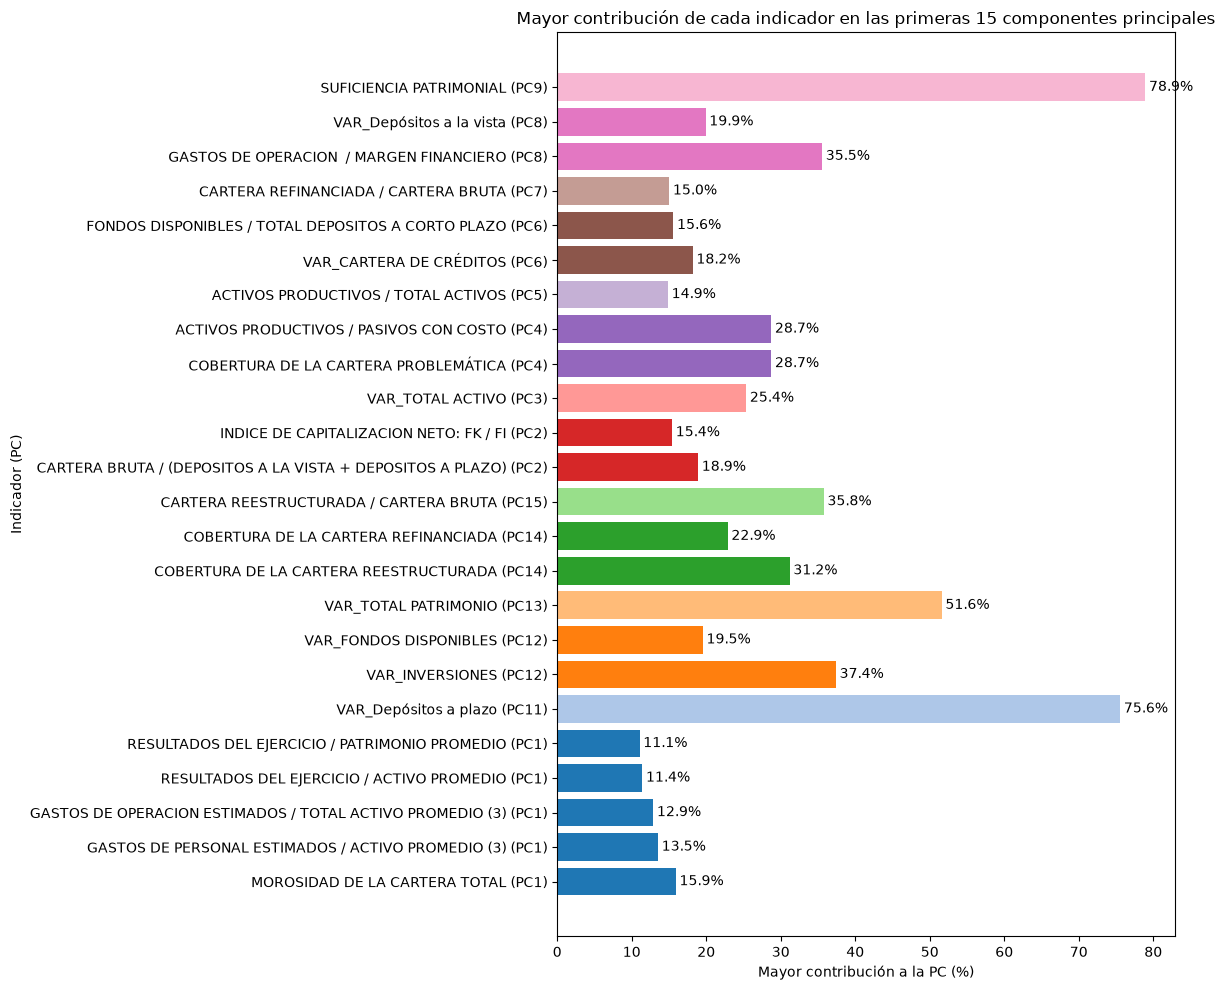

Gráfico guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\results\mayor_contribucion_pca.png


In [46]:
# Copia del resumen
df_grafico = resumen_contribuciones.copy()

# Ordenar por PC y luego por contribución
df_grafico = df_grafico.sort_values(
    ["PC con mayor contribución", "% mayor contribución"],
    ascending=[True, False]
)

# Obtener las PCs presentes
pcs = df_grafico["PC con mayor contribución"].unique()

# Crear una paleta con un color diferente para cada PC
colores = sns.color_palette("tab20", n_colors=len(pcs))

# Diccionario PC -> color
colores_pc = dict(zip(pcs, colores))

# Asignar color a cada barra según su PC
colores_barras = [
    colores_pc[pc]
    for pc in df_grafico["PC con mayor contribución"]
]

plt.figure(figsize=(12, 10))

y_pos = range(len(df_grafico))

plt.barh(
    y_pos,
    df_grafico["% mayor contribución"],
    color=colores_barras
)

# Etiquetas del eje Y
plt.yticks(
    y_pos,
    [
        f"{indicador} ({pc})"
        for indicador, pc in zip(
            df_grafico["Indicador"],
            df_grafico["PC con mayor contribución"]
        )
    ]
)

plt.xlabel("Mayor contribución a la PC (%)")
plt.ylabel("Indicador (PC)")

plt.title(
    "Mayor contribución de cada indicador en las primeras 15 componentes principales"
)

# Porcentaje al final de cada barra
for i, valor in enumerate(df_grafico["% mayor contribución"]):
    plt.text(
        valor + 0.5,
        i,
        f"{valor:.1f}%",
        va="center"
    )

plt.tight_layout()
# Guardar como resultado del PCA
ruta_figura = RAIZ_PROYECTO / "results" / "mayor_contribucion_pca.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Gráfico guardado en: {ruta_figura.resolve()}")

Es interesante observar que el gráfico al revelar qué indicador presenta su mayor contribución dentro de las primeras 15 componentes, algunas variables tienen una contribución particularmente elevada:

* Suficiencia patrimonial → PC9: 78,9% (Suficiencia)  
* Variación de depósitos a plazo → PC11: 75,6%  (Crecimiento)
* Variación del patrimonio → PC13: 51,6% (Crecimiento)
* Cartera reestructurada / cartera bruta → PC15: 35,8% (Composición de la cartera)
* Variación de inversiones → PC12: 37,4% (Crecimiento)
* Gastos de operación / margen financiero → PC8: 35,5% (Eficiencia microeconómica)
* Activos productivos / pasivos con costo y cobertura de cartera problemática → PC4: 28,7% (Estructura y calidad de activos y cobertura de cartera)
* Variación del total de activos → PC3: 25,4% (Crecimiento)

***Las categorías entre paréntesis corresponden a una clasificación temática de los indicadores utilizada para facilitar la interpretación financiera de las componentes.***

Esto es útil porque muestra que no todas las componentes están dominadas por múltiples indicadores de manera uniforme. Algunas presentan un indicador claramente dominante.

En las primeras componentes también se identifican conjuntos de indicadores relacionados con morosidad, eficiencia y rentabilidad, particularmente en PC1, donde la morosidad total representa el 15,9% de contribución de las variables a PC1, y el ROE y el ROA suman una contribución del 22,5% a PC1.

Estos resultados permiten complementar el análisis de las cargas y facilitan la interpretación económica de las componentes principales, al identificar las variables que tienen mayor participación relativa en su construcción.

In [47]:
print(
    tabla_contribuciones.sum(axis=0)
)

PC1     100.0
PC2     100.0
PC3     100.0
PC4     100.0
PC5     100.0
PC6     100.0
PC7     100.0
PC8     100.0
PC9     100.0
PC10    100.0
PC11    100.0
PC12    100.0
PC13    100.0
PC14    100.0
PC15    100.0
PC16    100.0
PC17    100.0
PC18    100.0
PC19    100.0
PC20    100.0
PC21    100.0
PC22    100.0
PC23    100.0
PC24    100.0
dtype: float64


### Heatmaps de las cargas y contribución de las componentes

In [48]:
componentes_90 = np.argmax(varianza_acumulada >= 90) + 1

print("Componentes para alcanzar el 90%:", componentes_90)

Componentes para alcanzar el 90%: 15


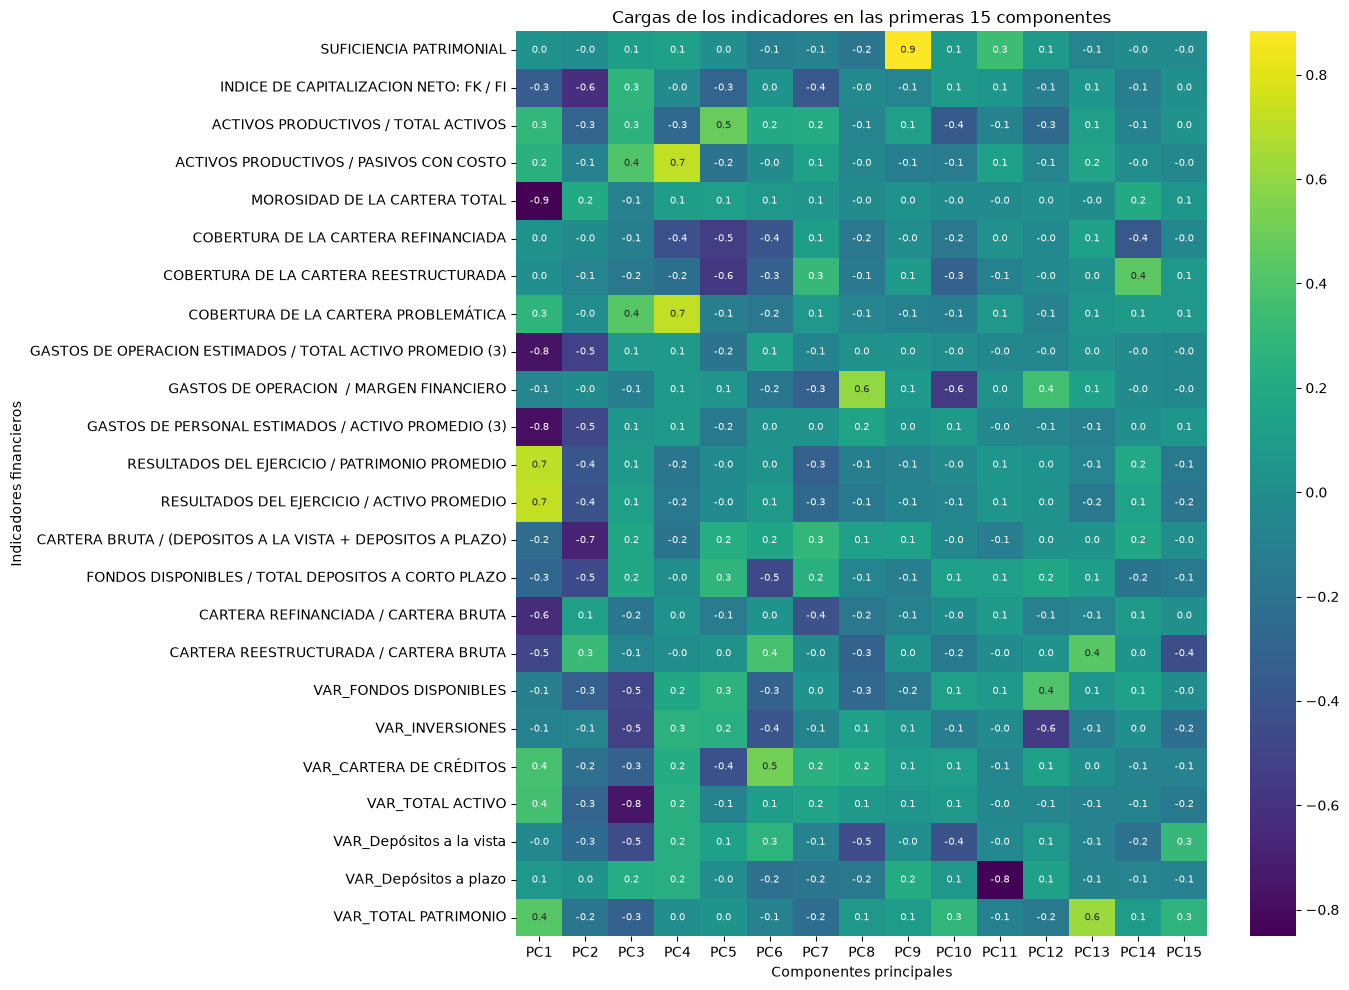

Heatmap guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\images\heatmap_cargas_pca.png


In [49]:

k = 15  # Número de componentes que alcanzan el 90% de la varianza explicada

plt.figure(figsize=(14, 10))

sns.heatmap(
    tabla_cargas.iloc[:, :k],
    cmap="viridis",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7}
)

plt.title(
    f"Cargas de los indicadores en las primeras {k} componentes"
)

plt.xlabel("Componentes principales")
plt.ylabel("Indicadores financieros")

plt.tight_layout()
# Guardar heatmap en la carpeta images
ruta_figura = RAIZ_PROYECTO / "images" / "heatmap_cargas_pca.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Heatmap guardado en: {ruta_figura.resolve()}")



El heatmap permite identificar la relación de cada indicador financiero con las primeras 15 componentes principales, considerando tanto la magnitud como el signo de las cargas. 

He aquí la intepretación de las más notables:

1. La PC1 presenta las cargas más elevadas en:

* Morosidad de la cartera total: -0,9
* Gastos de operación estimados / total activo promedio: -0,8
* Gastos de personal estimados / activo promedio: -0,8
* Resultados del ejercicio / patrimonio promedio: +0,7
* Resultados del ejercicio / activo promedio: +0,7
* Cartera refinanciada / cartera bruta: -0,6

Esto sugiere que PC1 combina principalmente calidad de cartera, eficiencia de gastos y rentabilidad.

El signo negativo de morosidad y gastos, frente al signo positivo de rentabilidad, permite interpretar esta dimensión como un eje que contrapone mejores resultados de rentabilidad frente a mayores niveles de morosidad y gastos relativos.

2. En PC2 destacan:

* Cartera bruta / (depósitos a la vista + depósitos a plazo): -0,7
* Índice de capitalización neto: -0,6
* Gastos de operación estimados / total activo promedio: -0,5
* Gastos de personal estimados / activo promedio: -0,5
* Fondos disponibles / total depósitos a corto plazo: -0,5

La componente está relacionada principalmente con la estructura de intermediación financiera y capitalización, junto con aspectos de liquidez y eficiencia.

3. PC3 está claramente dominada por:

* VAR_TOTAL ACTIVO: -0,8
* VAR_FONDOS DISPONIBLES: -0,5
* VAR_INVERSIONES: -0,5

y presenta algunas cargas positivas menores en activos productivos y cobertura. Esto indica que la componente está relacionada principalmente con la dinámica de crecimiento de los principales indicadores, siendo dominante los activos, e implica que al ser las cargas negativas de PC3 a mayores valores de los indicadores de crecimiento del activo, fondos disponibles e inversiones se asocian con menores scores de PC3, mientras que menores valores de estos indicadores se asocian con mayores scores de PC3, manteniendo constantes conceptualmente las demás variables de la combinación.

4. PC11 está claramente dominada por:

* VAR_Depósitos a plazo: -0,8

La carga negativa indica una relación inversa entre el indicador estandarizado de crecimiento interanual de los depósitos a plazo y el score de PC11. Por tanto, mayores valores del crecimiento interanual de los depósitos a plazo se asocian con menores valores del score de PC11, mientras que menores valores del indicador se asocian con mayores valores del score de PC11.


Por lo tanto, PC1 concentra relaciones importantes con indicadores de morosidad, eficiencia y rentabilidad, por lo que puede interpretarse como una dimensión de desempeño financiero integral. 

Otras componentes presentan dimensiones más específicas: PC3 se relaciona principalmente con la dinámica de los activos; PC4 con la estructura de activos y cobertura de cartera; PC9 con la suficiencia patrimonial; PC11 con el crecimiento de los depósitos a plazo; PC12 con la dinámica de inversiones; PC13 con la variación del patrimonio; y PC14–PC15 con aspectos relacionados con la cartera reestructurada y su cobertura. 


En consecuencia, las componentes posteriores al primer componente no deben interpretarse únicamente como dimensiones de menor importancia, sino como dimensiones financieras específicas que capturan fuentes diferenciadas de variabilidad presentes en las entidades analizadas.

Como complemento del Heatmap de cargas se incluye el de contribuciones, y de igual manera se consideran las 15 primeras componentes principales que abarcan cerca del 91% de la varianza explicada del dataset original.

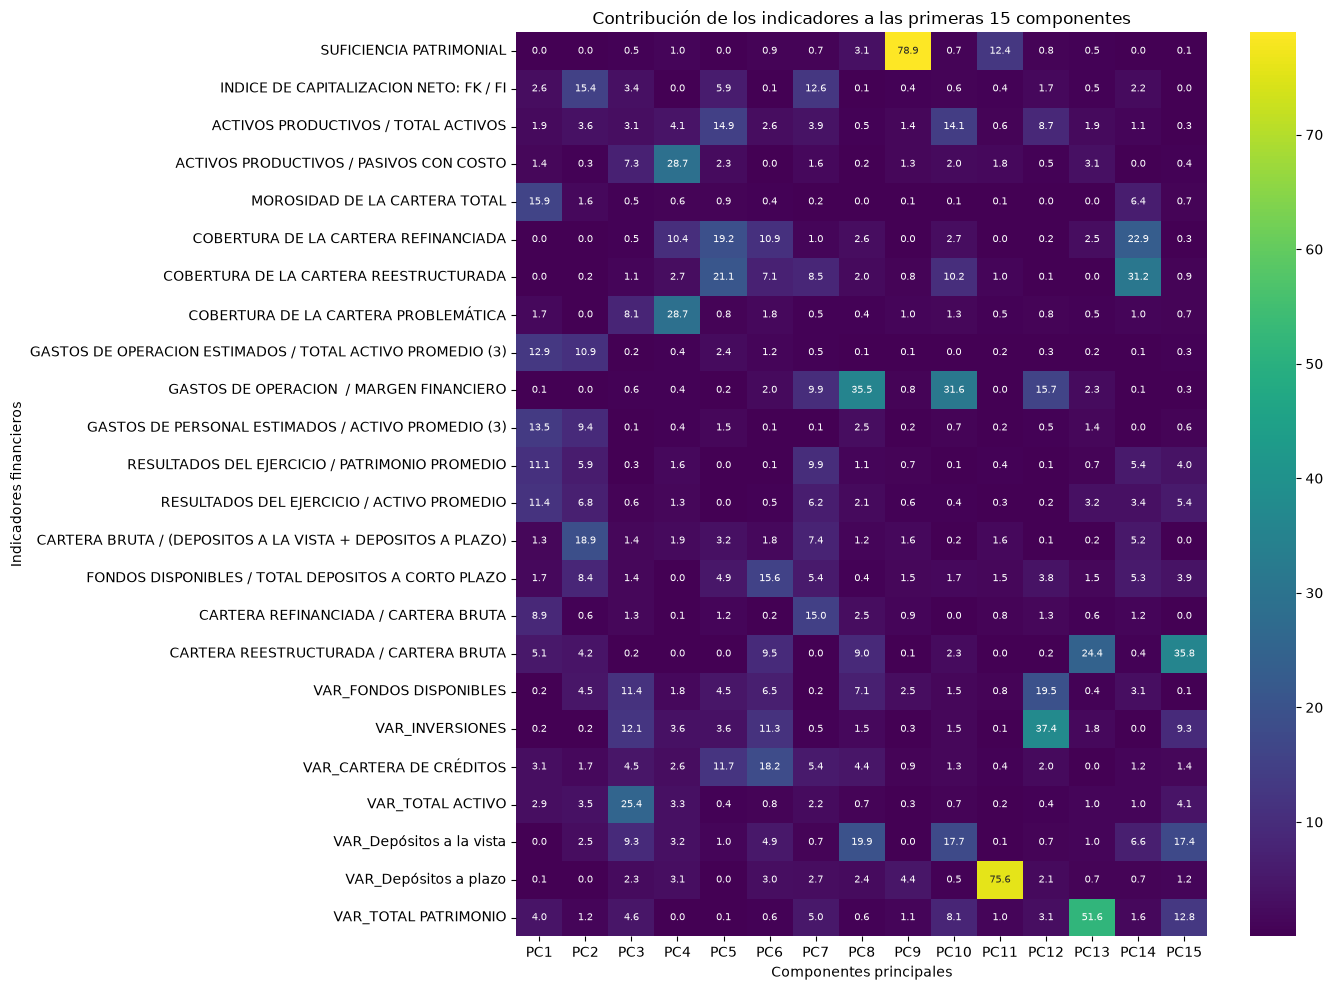

Heatmap guardado en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\images\heatmap_contribuciones_pca.png


In [50]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    tabla_contribuciones.iloc[:, :componentes_90],
    cmap="viridis",
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7}
)

plt.title(
    f"Contribución de los indicadores a las primeras {componentes_90} componentes"
)

plt.xlabel("Componentes principales")
plt.ylabel("Indicadores financieros")

plt.tight_layout()

# Guardar el heatmap en images
ruta_figura = RAIZ_PROYECTO / "images" / "heatmap_contribuciones_pca.png"
ruta_figura.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    ruta_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Heatmap guardado en: {ruta_figura.resolve()}")

Aquí ya no es distintivo el signo de la contribución, puesto que todas son mayores a 0 y lo que se interpreta es la magnitud.

El heatmap muestra concentraciones importantes de contribución en determinadas componentes:

* PC1: Morosidad de la cartera total → 15,9%; gastos de personal → 13,5%; gastos de operación / activo → 12,9%; rentabilidad sobre activo → 11,4% y rentabilidad sobre patrimonio → 11,1%.
* PC2: Cartera bruta / depósitos → 18,9% e índice de capitalización neto → 15,4%.
* PC3: Variación del total de activos → 25,4%.
* PC4: Activos productivos / pasivos con costo → 28,7% y cobertura de cartera problemática → 28,7%.
* PC8: Gastos de operación / margen financiero → 35,5%.
* PC9: Suficiencia patrimonial → 78,9%.
* PC11: Variación de depósitos a plazo → 75,6%.
* PC12: Variación de inversiones → 37,4%.
* PC13: Variación del total patrimonio → 51,6%.
* PC14: Cobertura de cartera reestructurada → 31,2%.
* PC15: Cartera reestructurada / cartera bruta → 35,8%.

Esto confirma algo importante que ya se había observado en el gráfico anterior: algunas componentes están definidas por una combinación de varios indicadores, mientras que otras están fuertemente dominadas por un indicador específico.

En resumen PC1 presenta una contribución distribuida entre varios indicadores asociados con morosidad, eficiencia y rentabilidad, mientras que otras componentes presentan una concentración mucho mayor en determinados indicadores. Entre estas destacan PC9, donde la suficiencia patrimonial representa el 78,9% de la contribución; PC11, dominada por la variación de los depósitos a plazo con 75,6%; y PC13, donde la variación del patrimonio alcanza el 51,6%. Asimismo, PC4 presenta contribuciones relevantes de los indicadores de activos productivos y cobertura de cartera problemática, mientras que PC12 y PC15 se relacionan principalmente con la dinámica de inversiones y la cartera reestructurada, respectivamente. 

Estos resultados complementan el análisis de las cargas y permiten identificar las variables que tienen mayor peso en la construcción e interpretación financiera de cada componente principal.

## 8. Interpretación de los componentes principales de acuerdo a las cargas y a su contribución



La interpretación de las componentes principales se realiza utilizando conjuntamente las cargas y las contribuciones obtenidas mediante PCA. Las cargas permiten determinar la dirección e intensidad de la relación entre cada indicador y la componente, mientras que las contribuciones permiten identificar el peso relativo de cada indicador en la construcción de la componente.

Para esta interpretación se consideran las cinco variables con mayor relevancia en cada componente, de acuerdo con el ranking de cargas y contribuciones.

Dado que las primeras 15 componentes principales explican aproximadamente el 91% de la variabilidad total, estas componentes permiten conservar una proporción elevada de la información contenida en los 24 indicadores originales. Por este motivo, el análisis financiero se concentra en las primeras 15 componentes.

> **Nota:** Las denominaciones asignadas a las componentes constituyen interpretaciones propuestas a partir de las cargas y contribuciones observadas. No corresponden a nombres estadísticos oficiales de las componentes principales.

---

### PC1 — Desempeño financiero integral

Las principales variables que caracterizan PC1 son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| MOROSIDAD DE LA CARTERA TOTAL | -0,852 | 15,91% |
| GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3) | -0,785 | 13,52% |
| GASTOS DE OPERACIÓN ESTIMADOS / TOTAL ACTIVO PROMEDIO (3) | -0,766 | 12,89% |
| RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO | +0,721 | 11,41% |
| RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO | +0,710 | 11,05% |

La MOROSIDAD DE LA CARTERA TOTAL presenta una carga de **-0,852**, lo que representa una relación de alta intensidad y dirección negativa con PC1. Esto significa que, manteniendo la interpretación del componente, mayores valores estandarizados de morosidad se asocian con menores valores del score de PC1. Su contribución de 15,91% evidencia que tiene un peso importante en la construcción de esta componente.

Los GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO presentan una carga de -0,785 y una contribución de 13,52%. La dirección negativa indica que mayores valores estandarizados de este indicador se asocian con menores valores de PC1. Su magnitud muestra una relación fuerte con la componente.

De manera similar, los GASTOS DE OPERACIÓN ESTIMADOS / TOTAL ACTIVO PROMEDIO presentan una carga de -0,766 y una contribución de 12,89%, por lo que constituyen otro elemento importante asociado negativamente con PC1.

En contraste,RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO, indicador asociado con la rentabilidad sobre los activos, presenta una carga positiva de +0,721 y una contribución de 11,41%. Esto indica que mayores valores estandarizados de este indicador se asocian con mayores valores del score de PC1.

Finalmente, RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO, relacionado con la rentabilidad sobre el patrimonio, presenta una carga de +0,710 y una contribución de 11,05%, mostrando también una relación positiva y de magnitud elevada.

En conjunto, PC1 integra indicadores que representan **calidad de cartera, eficiencia de gastos y rentabilidad**. Debido a que la morosidad permite aproximar el nivel de deterioro de la cartera, mientras que los indicadores de resultados permiten evaluar la rentabilidad y los indicadores de gastos reflejan aspectos de eficiencia, esta combinación puede interpretarse como una dimensión de **desempeño financiero integral**.

---

### PC2 — Intermediación y capitalización

Las cinco variables principales de PC2 son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| CARTERA BRUTA / (DEPÓSITOS A LA VISTA + DEPÓSITOS A PLAZO) | -0,687 | 18,90% |
| ÍNDICE DE CAPITALIZACIÓN NETO: FK / FI | -0,620 | 15,41% |
| GASTOS DE OPERACIÓN ESTIMADOS / TOTAL ACTIVO PROMEDIO (3) | -0,521 | 10,88% |
| GASTOS DE PERSONAL ESTIMADOS / ACTIVO PROMEDIO (3) | -0,484 | 9,36% |
| FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO | -0,459 | 8,42% |

La variable CARTERA BRUTA / (DEPÓSITOS A LA VISTA + DEPÓSITOS A PLAZO) presenta una carga de -0,687 y una contribución de 18,90%. Su signo negativo indica una relación inversa con PC2, mientras que su magnitud evidencia una relación relativamente fuerte.

El ÍNDICE DE CAPITALIZACIÓN NETO: FK / FI presenta una carga de -0,620 y una contribución de 15,41%, por lo que también constituye una variable relevante para la definición de esta componente.

Los indicadores de gastos de operación y gastos de personal presentan cargas negativas de -0,521 y -0,484, respectivamente, y contribuciones de 10,88% y 9,36%. Por tanto, ambos incorporan información relacionada con la estructura de gastos de las entidades.

Finalmente, FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO presenta una carga de -0,459 y una contribución de 8,42%, incorporando información relacionada con la posición relativa de fondos disponibles frente a depósitos de corto plazo.

En conjunto, PC2 combina información sobre la relación entre cartera y depósitos, capitalización, estructura de gastos y disponibilidad de recursos frente a obligaciones de corto plazo. Por esta razón, se propone interpretarla como una dimensión de **intermediación financiera y capitalización**.

---

### PC3 — Dinámica de activos

Las principales variables de PC3 son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| VAR_TOTAL ACTIVO | -0,752 | 25,35% |
| VAR_INVERSIONES | -0,519 | 12,08% |
| VAR_FONDOS DISPONIBLES | -0,504 | 11,39% |
| VAR_Depósitos a la vista | -0,455 | 9,30% |
| COBERTURA DE LA CARTERA PROBLEMÁTICA | +0,424 | 8,07% |

VAR_TOTAL ACTIVO presenta una carga de -0,752 y una contribución de 25,35%, siendo la variable con mayor peso en la construcción de PC3. La dirección negativa indica que mayores valores estandarizados del crecimiento del activo total se asocian con menores scores de PC3.

VAR_INVERSIONES presenta una carga de -0,519 y una contribución de 12,08%, mientras que VAR_FONDOS DISPONIBLES presenta una carga de -0,504 y una contribución de 11,39%. Ambas variables incorporan información sobre la evolución de diferentes componentes del activo.

La VAR_Depósitos a la vista presenta una carga de -0,455** y una contribución de 9,30%, mientras que la **COBERTURA DE LA CARTERA PROBLEMÁTICA** presenta una carga positiva de **+0,424** y una contribución de 8,07%.

En conjunto, las variables predominantes están relacionadas con la **variación del activo, inversiones y fondos disponibles**, por lo que PC3 puede interpretarse como una dimensión de **dinámica o crecimiento de los activos**.

---

### PC4 — Cobertura y productividad de activos

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| COBERTURA DE LA CARTERA PROBLEMÁTICA | +0,717 | 28,72% |
| ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO | +0,717 | 28,72% |
| COBERTURA DE LA CARTERA REFINANCIADA | -0,431 | 10,39% |
| ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS | -0,270 | 4,07% |
| VAR_INVERSIONES | +0,254 | 3,61% |

La **COBERTURA DE LA CARTERA PROBLEMÁTICA** presenta una carga positiva de **+0,717** y una contribución de **28,72%**, mientras que **ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO** presenta una carga prácticamente idéntica de **+0,717** y una contribución también de **28,72%**.

Esto indica que ambas variables tienen una relación positiva y fuerte con PC4 y, además, presentan un peso muy similar en su construcción.

Por otro lado, la **COBERTURA DE LA CARTERA REFINANCIADA** presenta una carga negativa de **-0,431** y una contribución de **10,39%**, mostrando una relación inversa y de intensidad moderada.

La combinación de indicadores de cobertura y productividad de activos permite interpretar PC4 como una dimensión relacionada con la **cobertura de cartera problemática y la capacidad de mantener activos productivos respecto de los pasivos con costo**.

---

### PC5 — Estructura de activos y cobertura

Las variables más relevantes son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| COBERTURA DE LA CARTERA REESTRUCTURADA | -0,569 | 21,10% |
| COBERTURA DE LA CARTERA REFINANCIADA | -0,543 | 19,19% |
| ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS | +0,477 | 14,86% |
| VAR_CARTERA DE CRÉDITOS | -0,424 | 11,75% |
| ÍNDICE DE CAPITALIZACIÓN NETO: FK / FI | -0,300 | 5,87% |

Las coberturas de cartera reestructurada y refinanciada presentan cargas negativas de **-0,569** y **-0,543**, con contribuciones de **21,10%** y **19,19%**, respectivamente.

En contraste, **ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS** presenta una carga positiva de **+0,477** y una contribución de **14,86%**. Esto establece una relación de dirección opuesta entre este indicador y las variables de cobertura predominantes.

La **VAR_CARTERA DE CRÉDITOS** presenta una carga de **-0,424** y una contribución de **11,75%**, incorporando información sobre la evolución de la cartera.

En conjunto, PC5 combina información relacionada con la **estructura productiva de los activos y los niveles de cobertura de cartera refinanciada y reestructurada**, por lo que se interpreta como una dimensión de **estructura de activos y cobertura**.

---

### PC6 — Crecimiento de cartera y liquidez

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| VAR_CARTERA DE CRÉDITOS | +0,512 | 18,18% |
| FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO | -0,474 | 15,59% |
| VAR_INVERSIONES | -0,403 | 11,27% |
| COBERTURA DE LA CARTERA REFINANCIADA | -0,396 | 10,88% |
| CARTERA REESTRUCTURADA / CARTERA BRUTA | +0,370 | 9,50% |

**VAR_CARTERA DE CRÉDITOS** presenta una carga positiva de **+0,512** y una contribución de **18,18%**, indicando una relación directa y de magnitud moderada con PC6.

En contraste, **FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO** presenta una carga de **-0,474** y una contribución de **15,59%**. Por tanto, ambas variables presentan direcciones opuestas dentro de la combinación lineal de PC6.

La **VAR_INVERSIONES** presenta una carga de **-0,403** y una contribución de **11,27%**, mientras que la **COBERTURA DE LA CARTERA REFINANCIADA** presenta una carga de **-0,396** y una contribución de **10,88%**.

Finalmente, **CARTERA REESTRUCTURADA / CARTERA BRUTA** presenta una carga positiva de **+0,370** y una contribución de **9,50%**.

En conjunto, PC6 combina principalmente información sobre **crecimiento de la cartera, disponibilidad de recursos frente a depósitos, evolución de inversiones y calidad/cobertura de cartera**, por lo que puede interpretarse como una dimensión de **crecimiento de cartera y liquidez**.

---

### PC7 — Cartera refinanciada, capitalización y eficiencia

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| CARTERA REFINANCIADA / CARTERA BRUTA | -0,413 | 15,03% |
| ÍNDICE DE CAPITALIZACIÓN NETO: FK / FI | -0,378 | 12,59% |
| RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO | -0,336 | 9,95% |
| GASTOS DE OPERACIÓN / MARGEN FINANCIERO | -0,336 | 9,92% |
| COBERTURA DE LA CARTERA REESTRUCTURADA | +0,310 | 8,48% |

La **CARTERA REFINANCIADA / CARTERA BRUTA** presenta una carga de **-0,413** y una contribución de **15,03%**, siendo el indicador con mayor peso dentro de esta componente.

El **ÍNDICE DE CAPITALIZACIÓN NETO** presenta una carga negativa de **-0,378** y una contribución de **12,59%**. Asimismo, los indicadores de rentabilidad y eficiencia presentan cargas negativas de magnitud similar, mientras que la **cobertura de cartera reestructurada** presenta una dirección positiva.

Por tanto, PC7 recoge una combinación de información relacionada con **cartera refinanciada, capitalización, rentabilidad, eficiencia y cobertura**, constituyendo una dimensión financiera más específica que las primeras componentes.

---

### PC8 — Eficiencia y dinámica de depósitos

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| GASTOS DE OPERACIÓN / MARGEN FINANCIERO | +0,604 | 35,54% |
| VAR_Depósitos a la vista | -0,452 | 19,91% |
| CARTERA REESTRUCTURADA / CARTERA BRUTA | -0,303 | 8,96% |
| VAR_FONDOS DISPONIBLES | -0,269 | 7,06% |
| VAR_CARTERA DE CRÉDITOS | +0,214 | 4,44% |

El **GASTO DE OPERACIÓN / MARGEN FINANCIERO** presenta una carga positiva de **+0,604** y una contribución de **35,54%**, por lo que tiene un peso predominante en la construcción de PC8.

La **VAR_Depósitos a la vista** presenta una carga negativa de **-0,452** y una contribución de **19,91%**, mostrando una relación inversa con PC8.

La combinación de ambas variables indica que esta componente recoge principalmente información sobre la **eficiencia operativa y la dinámica de los depósitos a la vista**.

Por ello, PC8 puede interpretarse como una dimensión de **eficiencia y dinámica de depósitos**.

---

### PC9 — Suficiencia patrimonial

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| SUFICIENCIA PATRIMONIAL | +0,883 | 78,93% |
| VAR_Depósitos a plazo | +0,208 | 4,37% |
| VAR_FONDOS DISPONIBLES | -0,157 | 2,51% |
| CARTERA BRUTA / (DEPÓSITOS A LA VISTA + DEPÓSITOS A PLAZO) | +0,127 | 1,63% |
| FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO | -0,122 | 1,51% |

La **SUFICIENCIA PATRIMONIAL** presenta una carga de **+0,883** y una contribución de **78,93%**, evidenciando una relación muy fuerte y un peso claramente predominante en la construcción de PC9.

Las demás variables presentan cargas y contribuciones considerablemente menores. Por tanto, PC9 está fuertemente caracterizada por la suficiencia patrimonial.

Dado que este indicador refleja la posición patrimonial de las entidades frente a los requerimientos asociados a sus riesgos, PC9 puede interpretarse como una dimensión específica de **suficiencia patrimonial y solvencia**.

---

### PC10 — Eficiencia operativa

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| GASTOS DE OPERACIÓN / MARGEN FINANCIERO | -0,556 | 31,59% |
| VAR_Depósitos a la vista | -0,415 | 17,66% |
| ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS | -0,371 | 14,07% |
| COBERTURA DE LA CARTERA REESTRUCTURADA | -0,316 | 10,19% |
| VAR_TOTAL PATRIMONIO | +0,282 | 8,14% |

El **GASTO DE OPERACIÓN / MARGEN FINANCIERO** presenta una carga de **-0,556** y una contribución de **31,59%**, siendo la variable de mayor peso en esta componente.

La **VAR_Depósitos a la vista** y **ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS** presentan cargas negativas de **-0,415** y **-0,371**, con contribuciones de **17,66%** y **14,07%**, respectivamente.

Por otro lado, la **VAR_TOTAL PATRIMONIO** presenta una carga positiva de **+0,282**, mostrando una dirección diferente respecto de las variables anteriores.

En conjunto, PC10 está caracterizada principalmente por indicadores de **eficiencia operativa**, acompañados por información sobre depósitos, estructura productiva de activos y evolución patrimonial. Por ello, se propone interpretarla como una dimensión de **eficiencia operativa**.

---

### PC11 — Dinámica de depósitos a plazo

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| VAR_Depósitos a plazo | -0,839 | 75,55% |
| SUFICIENCIA PATRIMONIAL | +0,340 | 12,43% |
| ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO | +0,128 | 1,77% |
| CARTERA BRUTA / (DEPÓSITOS A LA VISTA + DEPÓSITOS A PLAZO) | -0,120 | 1,55% |
| FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO | +0,116 | 1,46% |

La **VAR_Depósitos a plazo** presenta una carga de **-0,839** y una contribución de **75,55%**, mostrando una relación de alta intensidad y un peso predominante en la construcción de PC11.

Esto significa que mayores valores estandarizados de la variación de depósitos a plazo se asocian con menores valores del score de PC11. La **SUFICIENCIA PATRIMONIAL** presenta una carga positiva de **+0,340** y una contribución de **12,43%**, constituyendo la segunda variable con mayor peso.

Las demás variables presentan contribuciones considerablemente menores, por lo que su influencia en la caracterización de PC11 es más limitada.

En consecuencia, PC11 puede interpretarse principalmente como una dimensión de **dinámica o crecimiento de los depósitos a plazo**.

---

### PC12 — Dinámica de inversiones

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| VAR_INVERSIONES | -0,552 | 37,40% |
| VAR_FONDOS DISPONIBLES | +0,399 | 19,54% |
| GASTOS DE OPERACIÓN / MARGEN FINANCIERO | +0,358 | 15,72% |
| ACTIVOS PRODUCTIVOS / TOTAL ACTIVOS | -0,266 | 8,71% |
| FONDOS DISPONIBLES / TOTAL DEPÓSITOS A CORTO PLAZO | +0,176 | 3,79% |

**VAR_INVERSIONES** presenta una carga de **-0,552** y una contribución de **37,40%**, siendo la variable que más peso aporta a PC12.

Su dirección negativa indica que mayores valores estandarizados de la variación de inversiones se asocian con menores valores del score de PC12.

Por otro lado, **VAR_FONDOS DISPONIBLES** presenta una carga positiva de **+0,399** y una contribución de **19,54%**, mientras que **GASTOS DE OPERACIÓN / MARGEN FINANCIERO** presenta una carga positiva de **+0,358** y una contribución de **15,72%**.

En conjunto, PC12 está principalmente relacionada con la **evolución de las inversiones y los fondos disponibles**, por lo que se interpreta como una dimensión de **dinámica de inversiones**.

---

### PC13 — Dinámica patrimonial y cartera reestructurada

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| VAR_TOTAL PATRIMONIO | +0,625 | 51,60% |
| CARTERA REESTRUCTURADA / CARTERA BRUTA | +0,430 | 24,43% |
| RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO | -0,155 | 3,19% |
| ACTIVOS PRODUCTIVOS / PASIVOS CON COSTO | +0,153 | 3,10% |
| COBERTURA DE LA CARTERA REFINANCIADA | +0,137 | 2,47% |

**VAR_TOTAL PATRIMONIO** presenta una carga positiva de **+0,625** y una contribución de **51,60%**, por lo que representa más de la mitad de la contribución de las variables a esta componente.

La **CARTERA REESTRUCTURADA / CARTERA BRUTA** presenta una carga positiva de **+0,430** y una contribución de **24,43%**, constituyendo el segundo indicador más relevante.

En contraste, **RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO** presenta una carga negativa de **-0,155**, indicando una dirección opuesta dentro de la combinación lineal.

En conjunto, PC13 está dominada por la **variación del patrimonio**, acompañada por la participación de cartera reestructurada. Por ello, se puede interpretar principalmente como una dimensión de **dinámica patrimonial**, aunque incorpora adicionalmente información relacionada con la composición de cartera.

---

### PC14 — Cobertura de cartera reestructurada y refinanciada

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| COBERTURA DE LA CARTERA REESTRUCTURADA | +0,444 | 31,19% |
| COBERTURA DE LA CARTERA REFINANCIADA | -0,381 | 22,87% |
| VAR_Depósitos a la vista | -0,204 | 6,56% |
| MOROSIDAD DE LA CARTERA TOTAL | +0,201 | 6,37% |
| RESULTADOS DEL EJERCICIO / PATRIMONIO PROMEDIO | +0,185 | 5,43% |

La **COBERTURA DE LA CARTERA REESTRUCTURADA** presenta una carga positiva de **+0,444** y una contribución de **31,19%**, siendo la variable con mayor peso.

La **COBERTURA DE LA CARTERA REFINANCIADA** presenta una carga negativa de **-0,381** y una contribución de **22,87%**, mostrando una dirección opuesta a la cobertura de cartera reestructurada.

También se observa una carga negativa en **VAR_Depósitos a la vista** (-0,204), mientras que **MOROSIDAD DE LA CARTERA TOTAL** presenta una carga positiva de **+0,201**.

Por tanto, PC14 combina principalmente información relacionada con los **niveles de cobertura de cartera reestructurada y refinanciada**, por lo que puede interpretarse como una dimensión de **cobertura específica de cartera**.

---

### PC15 — Composición de cartera reestructurada

Las principales variables son:

| Indicador | Carga | Contribución |
|---|---:|---:|
| CARTERA REESTRUCTURADA / CARTERA BRUTA | -0,448 | 35,76% |
| VAR_Depósitos a la vista | +0,312 | 17,37% |
| VAR_TOTAL PATRIMONIO | +0,268 | 12,84% |
| VAR_INVERSIONES | -0,228 | 9,31% |
| RESULTADOS DEL EJERCICIO / ACTIVO PROMEDIO | -0,175 | 5,44% |

La **CARTERA REESTRUCTURADA / CARTERA BRUTA** presenta una carga negativa de **-0,448** y una contribución de **35,76%**, siendo la variable con mayor peso en PC15.

Esto indica que mayores valores estandarizados de la participación de cartera reestructurada se asocian con menores valores del score de PC15.

La **VAR_Depósitos a la vista** presenta una carga positiva de **+0,312** y una contribución de **17,37%**, mientras que **VAR_TOTAL PATRIMONIO** presenta una carga positiva de **+0,268** y una contribución de **12,84%**.

Por otro lado, **VAR_INVERSIONES** presenta una carga negativa de **-0,228**, con una contribución de **9,31%**.

En conjunto, PC15 está caracterizada principalmente por la **participación de la cartera reestructurada dentro de la cartera bruta**, acompañada por información sobre la evolución de depósitos, patrimonio e inversiones. Por ello, puede interpretarse como una dimensión relacionada con la **composición de la cartera reestructurada**.



El análisis conjunto de cargas y contribuciones permite observar que las primeras 15 componentes capturan diferentes dimensiones de la estructura financiera de las entidades. **PC1** presenta una naturaleza más integral, al combinar morosidad, eficiencia y rentabilidad, mientras que las componentes posteriores representan dimensiones progresivamente más específicas relacionadas con intermediación, capitalización, crecimiento de activos y cartera, liquidez, cobertura, suficiencia patrimonial, depósitos, inversiones y patrimonio.

Las contribuciones también muestran que algunas componentes están relativamente distribuidas entre varios indicadores, mientras que otras presentan una concentración elevada en una variable específica. Este comportamiento es especialmente evidente en **PC9**, donde la suficiencia patrimonial representa aproximadamente el **78,93%** de la contribución, y en **PC11**, donde la variación de los depósitos a plazo representa aproximadamente el 75,55%.

Estas diferencias son relevantes para la interpretación de los resultados, ya que permiten distinguir entre componentes que representan dimensiones financieras amplias y componentes que capturan características financieras específicas de las entidades.

Finalmente, dado que las primeras 15 componentes explican aproximadamente el 91% de la variabilidad total, mientras que las primeras 11 componentes explican aproximadamente el 80%, se consideran dos alternativas para la etapa de *clustering*: utilizar las componentes **PC1–PC11**, obteniendo una representación más parsimoniosa, o utilizar **PC1–PC15**, conservando una mayor proporción de la información original.

La selección final no se realizará únicamente con base en la varianza explicada. Ambas alternativas serán evaluadas mediante criterios de calidad, estabilidad e interpretabilidad de los agrupamientos, con el objetivo de determinar cuál representación permite obtener el mejor modelo de *clustering* y, principalmente, cuál permite perfilar de mejor manera a las entidades financieras según sus características e indicadores.

In [51]:
# Seleccionar identificadores + primeras 11 componentes
columnas_pc11 = [
    "ENTIDAD",
    "AÑO",
    "MES"
] + [f"PC{i}" for i in range(1, 12)]

df_pc11 = df_scores[columnas_pc11].copy()

# Definir ruta de salida
ruta_pc11 = RAIZ_PROYECTO / "data_processed" / "base_pca_pc11.xlsx"
ruta_pc11.parent.mkdir(parents=True, exist_ok=True)

# Exportar
df_pc11.to_excel(
    ruta_pc11,
    index=False
)

print(f"Base PC11 guardada en: {ruta_pc11.resolve()}")

Base PC11 guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\data_processed\base_pca_pc11.xlsx


In [52]:
# Seleccionar identificadores + primeras 15 componentes
columnas_pc15 = [
    "ENTIDAD",
    "AÑO",
    "MES"
] + [f"PC{i}" for i in range(1, 16)]

df_pc15 = df_scores[columnas_pc15].copy()

# Definir ruta de salida
ruta_pc15 = RAIZ_PROYECTO / "data_processed" / "base_pca_pc15.xlsx"
ruta_pc15.parent.mkdir(parents=True, exist_ok=True)

# Exportar
df_pc15.to_excel(
    ruta_pc15,
    index=False
)

print(f"Base PC15 guardada en: {ruta_pc15.resolve()}")

Base PC15 guardada en: C:\Users\ASUS\Desktop\proyecto_usfq\Proyecto_usfq\data_processed\base_pca_pc15.xlsx


## 9. Conclusiones

El análisis de componentes principales permitió reducir la dimensionalidad del conjunto de 24 indicadores financieros, identificando una estructura de dimensiones latentes que sintetizan diferentes aspectos del comportamiento de las entidades bancarias. Los resultados muestran que las primeras 11 componentes explican aproximadamente el 80% de la varianza total, mientras que las primeras 15 componentes alcanzan aproximadamente el 91%. Esto evidencia que es posible reducir la dimensionalidad de los indicadores originales manteniendo una proporción importante de la información contenida en los datos.

La primera componente concentra aproximadamente el 19% de la varianza y presenta cargas elevadas en indicadores de morosidad, eficiencia operativa y rentabilidad. Por esta estructura, la PC1 puede interpretarse como una dimensión asociada al desempeño financiero integral. A diferencia de algunas componentes posteriores, su contribución se encuentra distribuida entre varios indicadores, lo que indica que representa una dimensión transversal del comportamiento financiero y no un único indicador.

Las componentes posteriores permiten identificar dimensiones más específicas de la estructura financiera. Por ejemplo, la PC9 presenta una contribución predominante de la suficiencia patrimonial, mientras que la PC11 está fuertemente asociada con la variación de los depósitos a plazo. Asimismo, componentes como la PC12, PC13, PC14 y PC15 presentan contribuciones importantes de variables relacionadas con inversiones, patrimonio, cobertura y cartera reestructurada. Esto evidencia que el PCA permite identificar tanto dimensiones financieras generales como patrones específicos presentes en las entidades.

Para la etapa de clustering se utilizarán dos representaciones alternativas del espacio reducido: una conformada por las primeras 11 componentes, que explican aproximadamente el 80% de la varianza, y otra conformada por las primeras 15 componentes, que explican aproximadamente el 91%. Ambas representaciones serán utilizadas como entrada para un modelo de K-Means, con el propósito de evaluar si la incorporación de las componentes adicionales mejora la identificación y separación de los perfiles financieros. La selección de la representación y del número de grupos se realizará mediante múltiples métricas de evaluación del clustering y considerando también la interpretabilidad financiera de los grupos obtenidos.